In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/nasir-beep/Energy-consumption/main/Energy_consumption.csv')

In [3]:
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [4]:
df.shape

(1000, 11)

In [7]:
df.columns

Index(['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
       'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday',
       'EnergyConsumption'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


In [9]:
df.describe

<bound method NDFrame.describe of                Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0    2022-01-01 00:00:00    25.139433  43.431581    1565.693999          5   
1    2022-01-01 01:00:00    27.731651  54.225919    1411.064918          1   
2    2022-01-01 02:00:00    28.704277  58.907658    1755.715009          2   
3    2022-01-01 03:00:00    20.080469  50.371637    1452.316318          1   
4    2022-01-01 04:00:00    23.097359  51.401421    1094.130359          9   
..                   ...          ...        ...            ...        ...   
995  2022-02-11 11:00:00    28.619382  48.850160    1080.087000          5   
996  2022-02-11 12:00:00    23.836647  47.256435    1705.235156          4   
997  2022-02-11 13:00:00    23.005340  48.720501    1320.285281          6   
998  2022-02-11 14:00:00    25.138365  31.306459    1309.079719          3   
999  2022-02-11 15:00:00    23.051165  42.615421    1018.140606          6   

    HVACUsage LightingUsage  

In [10]:
#clean column names
df.columns = df.columns.str.strip()

In [11]:
#check missing values and duplicates
df.isnull().sum()

Timestamp            0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
DayOfWeek            0
Holiday              0
EnergyConsumption    0
dtype: int64

In [12]:
df.dropna()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732
...,...,...,...,...,...,...,...,...,...,...,...
995,2022-02-11 11:00:00,28.619382,48.850160,1080.087000,5,Off,Off,21.194696,Saturday,No,82.306692
996,2022-02-11 12:00:00,23.836647,47.256435,1705.235156,4,Off,On,25.748176,Tuesday,Yes,66.577320
997,2022-02-11 13:00:00,23.005340,48.720501,1320.285281,6,Off,On,0.297079,Friday,Yes,72.753471
998,2022-02-11 14:00:00,25.138365,31.306459,1309.079719,3,On,Off,20.425163,Thursday,Yes,76.950389


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [16]:
df.dtypes

Timestamp             object
Temperature          float64
Humidity             float64
SquareFootage        float64
Occupancy              int64
HVACUsage             object
LightingUsage         object
RenewableEnergy      float64
DayOfWeek             object
Holiday               object
EnergyConsumption    float64
dtype: object

In [22]:
#Encode categorical features- converting text into numbers
le = LabelEncoder()

categorical_cols = [
    'HVACUsage',
    'LightingUsage',
    'DayOfWeek',
    'Holiday'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [23]:
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,1,0,2.774699,1,0,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,1,1,21.831384,2,0,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,0,0,6.764672,3,0,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,0,1,8.623447,6,0,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,1,0,3.071969,0,0,70.811732


In [24]:
#create energy class from EnergyConsumption
df["Energy_Class"] = pd.qcut(
    df["EnergyConsumption"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [25]:
# check result
print(df[["EnergyConsumption", "Energy_Class"]].head())

   EnergyConsumption Energy_Class
0          75.364373       Medium
1          83.401855         High
2          78.270888       Medium
3          56.519850          Low
4          70.811732          Low


In [31]:
#select features and target
x = df.drop([
    "Energy_Class",
    "EnergyConsumption"
], axis=1)
y = df["Energy_Class"]

In [32]:
#Remove all timestamp related to columns
x = x.loc[:, ~x.columns.str.contains("Timestamp")]

In [33]:
print(x.shape)
print(y.shape)

(1000, 9)
(1000,)


In [34]:
print(x.columns)

Index(['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage',
       'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday'],
      dtype='object')


In [35]:
x = pd.get_dummies(x, drop_first=True)

In [36]:
# encode target
le = LabelEncoder()
y = le.fit_transform(y)

print(y[:5])

[2 0 2 1 1]


In [37]:
print(le.classes_)

['High' 'Low' 'Medium']


In [38]:
#Encode target column
print(y.dtype)

int64


In [39]:
print(x.shape)
print(y.shape)
print(type(y))

(1000, 9)
(1000,)
<class 'numpy.ndarray'>


In [40]:
#Split data into training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [41]:
print(x_train.shape)
print(x_test.shape)

(800, 9)
(200, 9)


In [42]:
#Train decision tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [43]:
#Train random forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
#Make predictions
dt_pred = dt_model.predict(x_test)
rf_pred = rf_model.predict(x_test)

In [45]:
print(dt_pred.shape)
print(rf_pred.shape)
print(y_test.shape)

(200,)
(200,)
(200,)


In [46]:
#Accuracy evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree Accuracy: 0.495
Random Forest Accuracy: 0.65


In [47]:
print(type(y_test))
print(y_test[:5])
print(dt_pred[:5])

<class 'numpy.ndarray'>
[0 0 2 0 0]
[2 0 2 0 2]


In [48]:
#Precision score
print(
    "Decision Tree Precision:",
    precision_score(
        y_test,
        dt_pred,
        average='weighted'
    )
)

Decision Tree Precision: 0.5044659856048294


In [49]:
print(
    "Random Forest Precision:",
    precision_score(
        y_test,
        rf_pred,
        average='weighted'
    )
)

Random Forest Precision: 0.6412266601323204


In [50]:
#Recall score
print(
    "Decision Tree Recall:",
    recall_score(
        y_test,
        dt_pred,
        average='weighted'
    )
)

Decision Tree Recall: 0.495


In [51]:
print(
    "Random Forest Recall:",
    recall_score(
        y_test,
        rf_pred,
        average='weighted'
    )
)

Random Forest Recall: 0.65


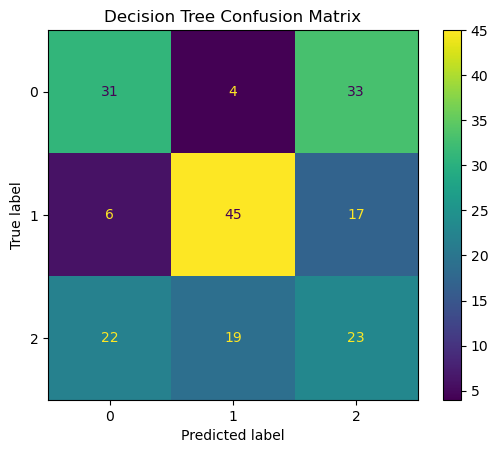

In [52]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

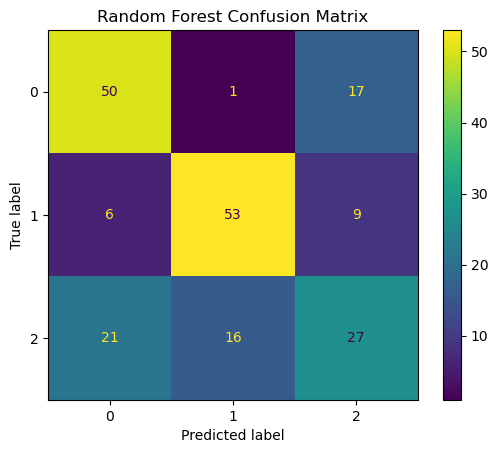

In [53]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [54]:
#Create comparison table
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, dt_pred, average='weighted'),
        precision_score(y_test, rf_pred, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, dt_pred, average='weighted'),
        recall_score(y_test, rf_pred, average='weighted')
    ]
})

In [55]:
print(results)

           Model  Accuracy  Precision  Recall
0  Decision Tree     0.495   0.504466   0.495
1  Random Forest     0.650   0.641227   0.650


In [56]:
#Save model
import joblib
joblib.dump(rf_model, "energy_model.pkl")

['energy_model.pkl']

In [265]:
joblib.dump(
    x.columns.tolist(),
    "feature_names.pkl"
)

['feature_names.pkl']